In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nChurn Distribution:\n", df['Churn'].value_counts())
print("\nChurn Rate:", df['Churn'].value_counts(normalize=True)['Yes'])

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
 customerID    

In [2]:
# Fix TotalCharges — convert to numeric, hidden spaces causing object type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check what got converted to NaN
print("Missing after conversion:", df['TotalCharges'].isnull().sum())

# Check those rows
print(df[df['TotalCharges'].isnull()])

Missing after conversion: 11
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             D

In [3]:
# Drop these 11 rows — new customers with no billing history
# Not relevant for churn analysis
df = df.dropna(subset=['TotalCharges'])
print("Shape after cleaning:", df.shape)

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verify
print("Churn Distribution after cleaning:")
print(df['Churn'].value_counts())
print(f"\nFinal Churn Rate: {df['Churn'].mean():.2%}")

# Save cleaned data
df.to_csv('../data/processed/telco_churn_cleaned.csv', index=False)
print("\nCleaned data saved.")

Shape after cleaning: (7032, 21)
Churn Distribution after cleaning:
Churn
0    5163
1    1869
Name: count, dtype: int64

Final Churn Rate: 26.58%

Cleaned data saved.


/var/folders/2f/czrxh5x11x31pyqwcsdn1t9w0000gn/T/ipykernel_87530/1759606974.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='Churn', ax=axes[0,1],
/var/folders/2f/czrxh5x11x31pyqwcsdn1t9w0000gn/T/ipykernel_87530/1759606974.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=internet_churn, x='InternetService', y='Churn',
/var/folders/2f/czrxh5x11x31pyqwcsdn1t9w0000gn/T/ipykernel_87530/1759606974.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn

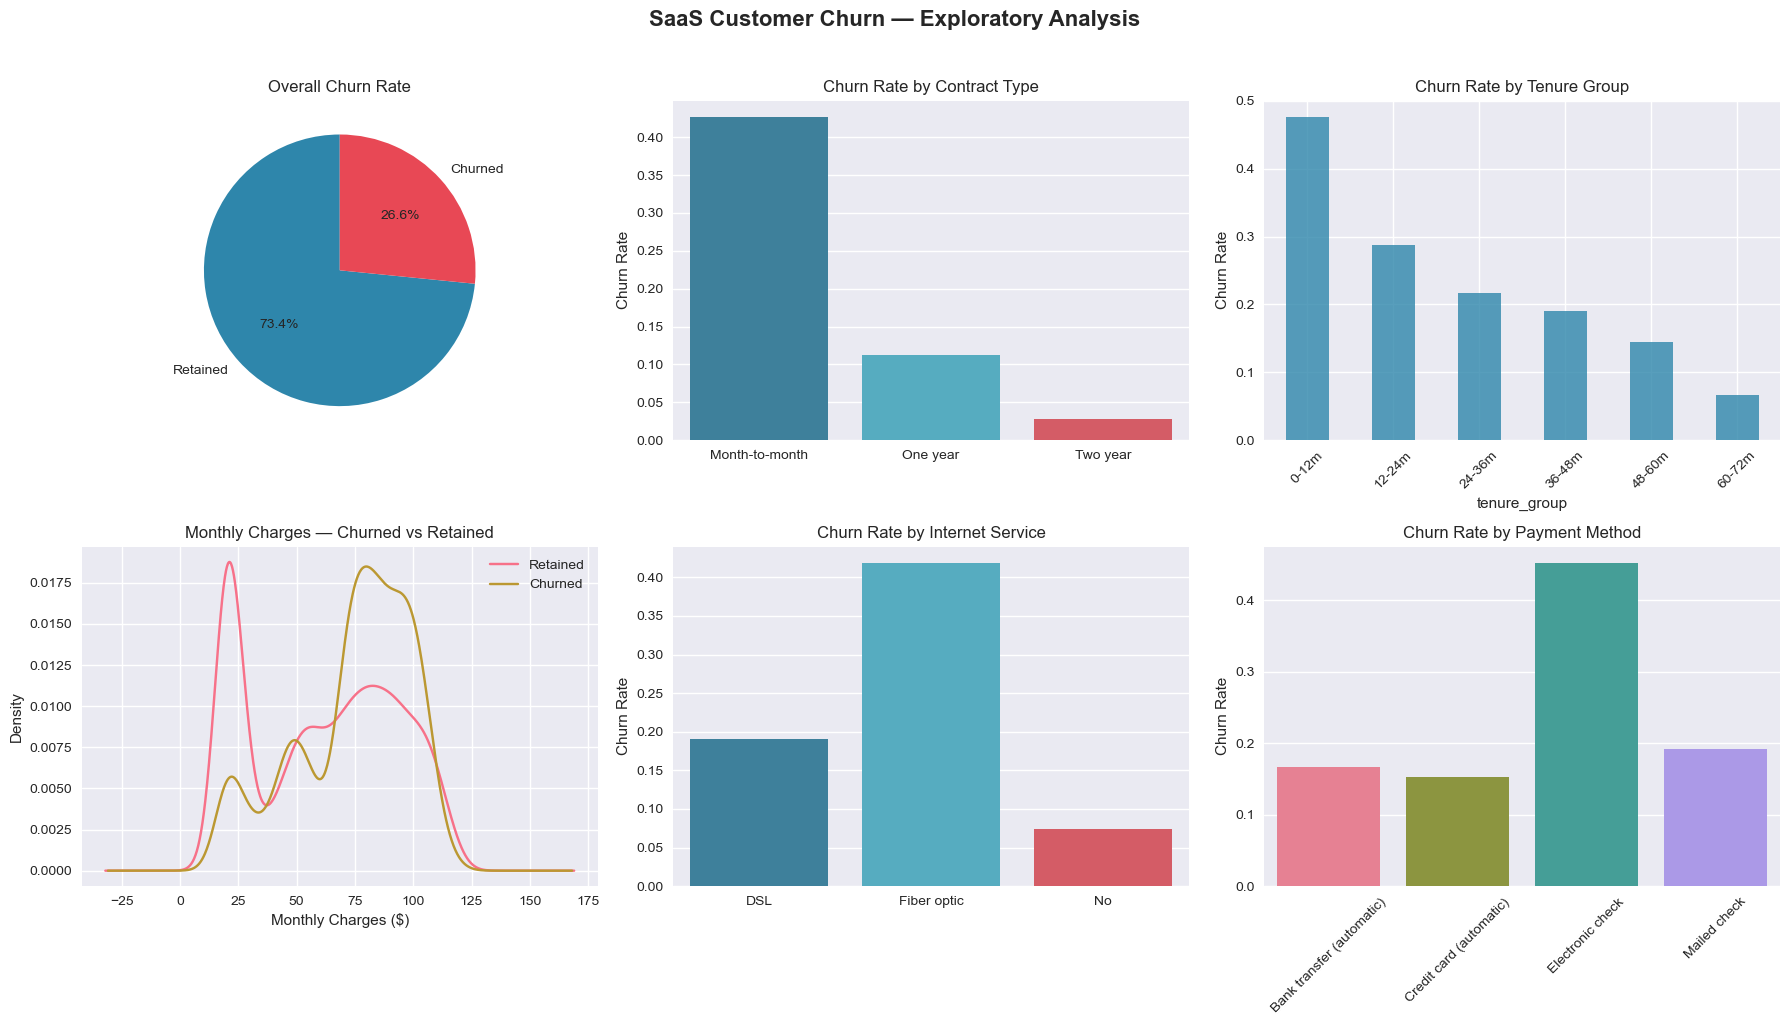

Plot saved.


In [4]:
# Set style for all plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SaaS Customer Churn — Exploratory Analysis', 
             fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Churn Distribution
axes[0,0].pie([5163, 1869], labels=['Retained', 'Churned'],
              autopct='%1.1f%%', colors=['#2E86AB','#E84855'],
              startangle=90)
axes[0,0].set_title('Overall Churn Rate')

# Plot 2: Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
sns.barplot(data=contract_churn, x='Contract', y='Churn', ax=axes[0,1],
            palette=['#2E86AB','#45B7D1','#E84855'])
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].set_xlabel('')

# Plot 3: Churn by Tenure
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0,12,24,36,48,60,72],
                             labels=['0-12m','12-24m','24-36m',
                                    '36-48m','48-60m','60-72m'])
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean()
tenure_churn.plot(kind='bar', ax=axes[0,2], color='#2E86AB', alpha=0.8)
axes[0,2].set_title('Churn Rate by Tenure Group')
axes[0,2].set_ylabel('Churn Rate')
axes[0,2].set_xticklabels(axes[0,2].get_xticklabels(), rotation=45)

# Plot 4: Monthly Charges Distribution
df.groupby('Churn')['MonthlyCharges'].plot(kind='kde', ax=axes[1,0],
                                            legend=True)
axes[1,0].set_title('Monthly Charges — Churned vs Retained')
axes[1,0].set_xlabel('Monthly Charges ($)')
axes[1,0].legend(['Retained','Churned'])

# Plot 5: Churn by Internet Service
internet_churn = df.groupby('InternetService')['Churn'].mean().reset_index()
sns.barplot(data=internet_churn, x='InternetService', y='Churn',
            ax=axes[1,1], palette=['#2E86AB','#45B7D1','#E84855'])
axes[1,1].set_title('Churn Rate by Internet Service')
axes[1,1].set_ylabel('Churn Rate')
axes[1,1].set_xlabel('')

# Plot 6: Churn by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().reset_index()
sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn',
            ax=axes[1,2], palette='husl')
axes[1,2].set_title('Churn Rate by Payment Method')
axes[1,2].set_ylabel('Churn Rate')
axes[1,2].set_xlabel('')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visuals/01_EDA_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved.")

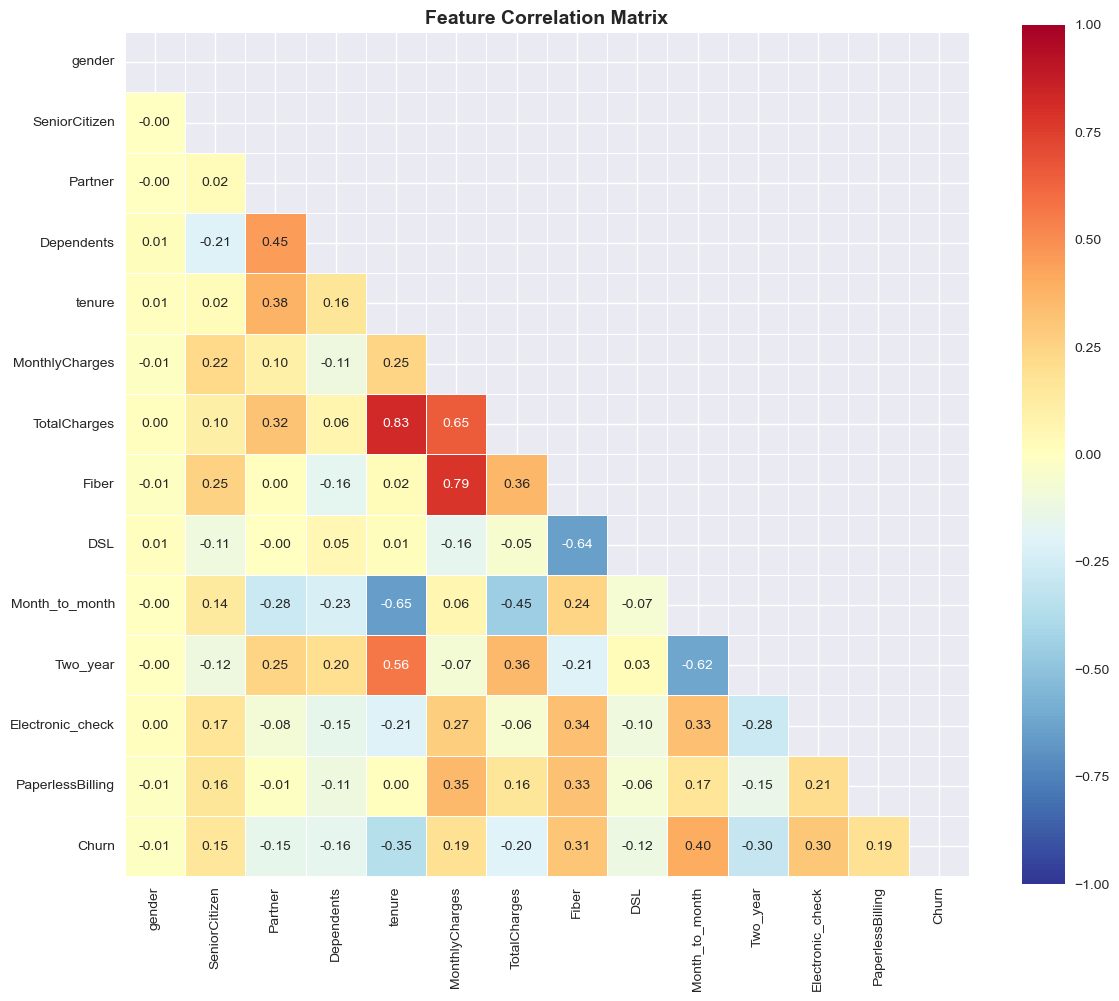


Top correlations with Churn:
Month_to_month      0.404565
tenure             -0.354049
Fiber               0.307463
Two_year           -0.301552
Electronic_check    0.301455
TotalCharges       -0.199484
MonthlyCharges      0.192858
PaperlessBilling    0.191454
Dependents         -0.163128
SeniorCitizen       0.150541
Name: Churn, dtype: float64


In [5]:
# Correlation Analysis
# Convert categorical variables to numeric for correlation

df_corr = df.copy()

# Binary encoding
binary_cols = ['Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling', 'MultipleLines']
for col in binary_cols:
    df_corr[col] = (df_corr[col] == 'Yes').astype(int)

# Internet service
df_corr['Fiber'] = (df_corr['InternetService'] == 'Fiber optic').astype(int)
df_corr['DSL'] = (df_corr['InternetService'] == 'DSL').astype(int)

# Contract
df_corr['Month_to_month'] = (df_corr['Contract'] == 'Month-to-month').astype(int)
df_corr['Two_year'] = (df_corr['Contract'] == 'Two year').astype(int)

# Payment
df_corr['Electronic_check'] = (df_corr['PaymentMethod'] == 'Electronic check').astype(int)

# Gender
df_corr['gender'] = (df_corr['gender'] == 'Male').astype(int)

# Select numeric columns
numeric_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                'tenure', 'MonthlyCharges', 'TotalCharges',
                'Fiber', 'DSL', 'Month_to_month', 'Two_year',
                'Electronic_check', 'PaperlessBilling', 'Churn']

corr_matrix = df_corr[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='RdYlBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with Churn
print("\nTop correlations with Churn:")
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr.head(10))